In [2]:
import sys
print(sys.executable)

!pip show gym-electric-motor


d:\Github\Machine-Learning-Studies\conda-env\python.exe
Name: gym_electric_motor
Version: 3.0.2
Summary: A Farama Gymnasium environment for electric motor control.
Home-page: 
Author: Arne Traue, Gerrit Book, Praneeth Balakrishna, Pascal Peters, Pramod Manjunatha, Darius Jakobeit, Felix Book, Max Schenke, Wilhelm Kirchgässner, Oliver Wallscheid, Barnabas Haucke-Korber, Stefan Arndt, Marius Köhler, Ranil Thomas
Author-email: 
License: 
Location: d:\github\machine-learning-studies\conda-env\lib\site-packages
Requires: gymnasium, matplotlib, numpy, pathspec, pytest, pytest-cov, scipy
Required-by: 


In [1]:
import gymnasium as gym
import gym_electric_motor

# Liệt kê tất cả env trong registry
env_ids = sorted([env.id for env in gym.envs.registry.values() if "ElectricMotor" in env.id or "PMSM" in env.id])
print("Các env GEM:")
for env_id in env_ids:
    print(env_id)



Các env GEM:
Cont-CC-PMSM-v0
Cont-SC-PMSM-v0
Cont-TC-PMSM-v0
Finite-CC-PMSM-v0
Finite-SC-PMSM-v0
Finite-TC-PMSM-v0


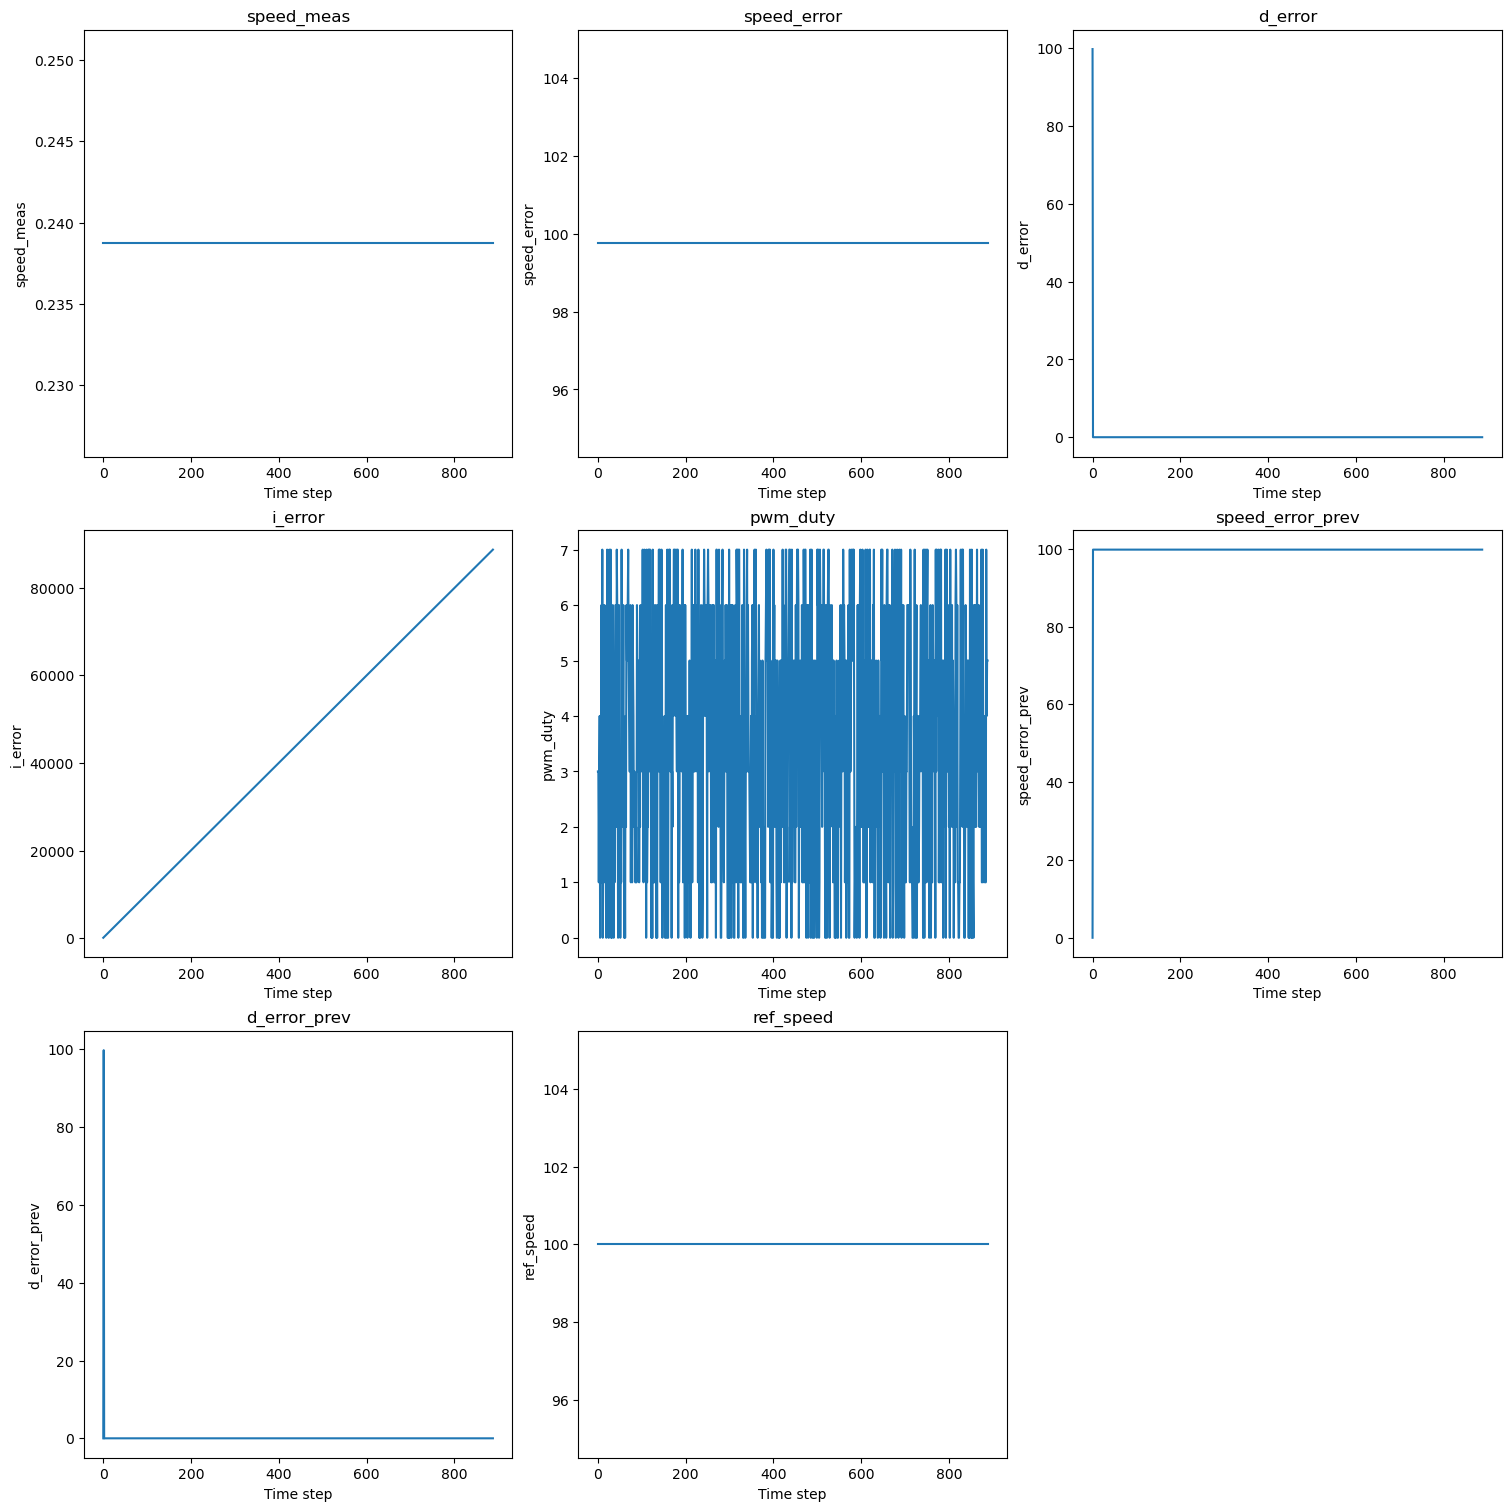

In [6]:
import gymnasium as gym
import gym_electric_motor
import matplotlib.pyplot as plt
import numpy as np

# Khởi tạo env
env = gym.make("Finite-CC-PMSM-v0")
obs, info = env.reset()

# Dataset chứa 8 input
data = {
    "speed_meas": [],
    "speed_error": [],
    "d_error": [],
    "i_error": [],
    "pwm_duty": [],
    "speed_error_prev": [],
    "d_error_prev": [],
    "ref_speed": [],
}

# Tham số ban đầu
done = False
step = 0
max_steps = 1000
ref_speed = 100.0  # tốc độ mục tiêu
prev_speed_error = 0.0
prev_d_error = 0.0
integral_error = 0.0

while not done and step < max_steps:
    # Lấy tốc độ đo (omega)
    speed_meas = obs[0][0]

    # Sai số tốc độ
    speed_error = ref_speed - speed_meas

    # Đạo hàm sai số
    d_error = speed_error - prev_speed_error

    # Tích phân sai số
    integral_error += speed_error

    # PWM duty (action) - ở đây mình random, RL sau sẽ thay
    action = env.action_space.sample()
    pwm_duty = action[0] if isinstance(action, (list, np.ndarray)) else action

    # Lưu dữ liệu
    data["speed_meas"].append(speed_meas)
    data["speed_error"].append(speed_error)
    data["d_error"].append(d_error)
    data["i_error"].append(integral_error)
    data["pwm_duty"].append(pwm_duty)
    data["speed_error_prev"].append(prev_speed_error)
    data["d_error_prev"].append(prev_d_error)
    data["ref_speed"].append(ref_speed)

    # Bước tiếp theo
    obs, reward, done, truncated, info = env.step(action)

    prev_speed_error = speed_error
    prev_d_error = d_error
    step += 1

# Vẽ chart
keys = list(data.keys())
num_plots = len(keys)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows), constrained_layout=True)

for i, key in enumerate(keys):
    r = i // cols
    c = i % cols
    ax = axs[r, c] if rows > 1 else axs[c]
    ax.plot(range(len(data[key])), data[key])
    ax.set_title(key)
    ax.set_xlabel("Time step")
    ax.set_ylabel(key)

# Ẩn subplot thừa
for j in range(num_plots, rows*cols):
    r = j // cols
    c = j % cols
    ax = axs[r, c] if rows > 1 else axs[c]
    ax.axis('off')

plt.show()


Action space: Discrete(8)
Observation space: Tuple(Box([-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  0.], 1.0, (14,), float64), Box(-0.6, 0.6, (2,), float64))
Initial observation: (array([ 0.23873241,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -1.4       , -1.4       , -1.4       ,
        0.        ,  0.        ,  0.        ,  1.        ]), array([ 0.17123878, -0.09764167]))
Step 0:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 614.00
Action: 7
---
Step 100:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 102.85
Action: 7
---
Step 200:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 103.36
Action: 7
---
Step 300:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 103.87
Action: 7
---
Step 400:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 104.38
Action: 7
---
Step 500:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 104.90
Action: 7
---
Step 600:
Speed: 0.24 rad/s (2.28 RPM)
Error: 10.23
Control: 105.41
Action: 7
---

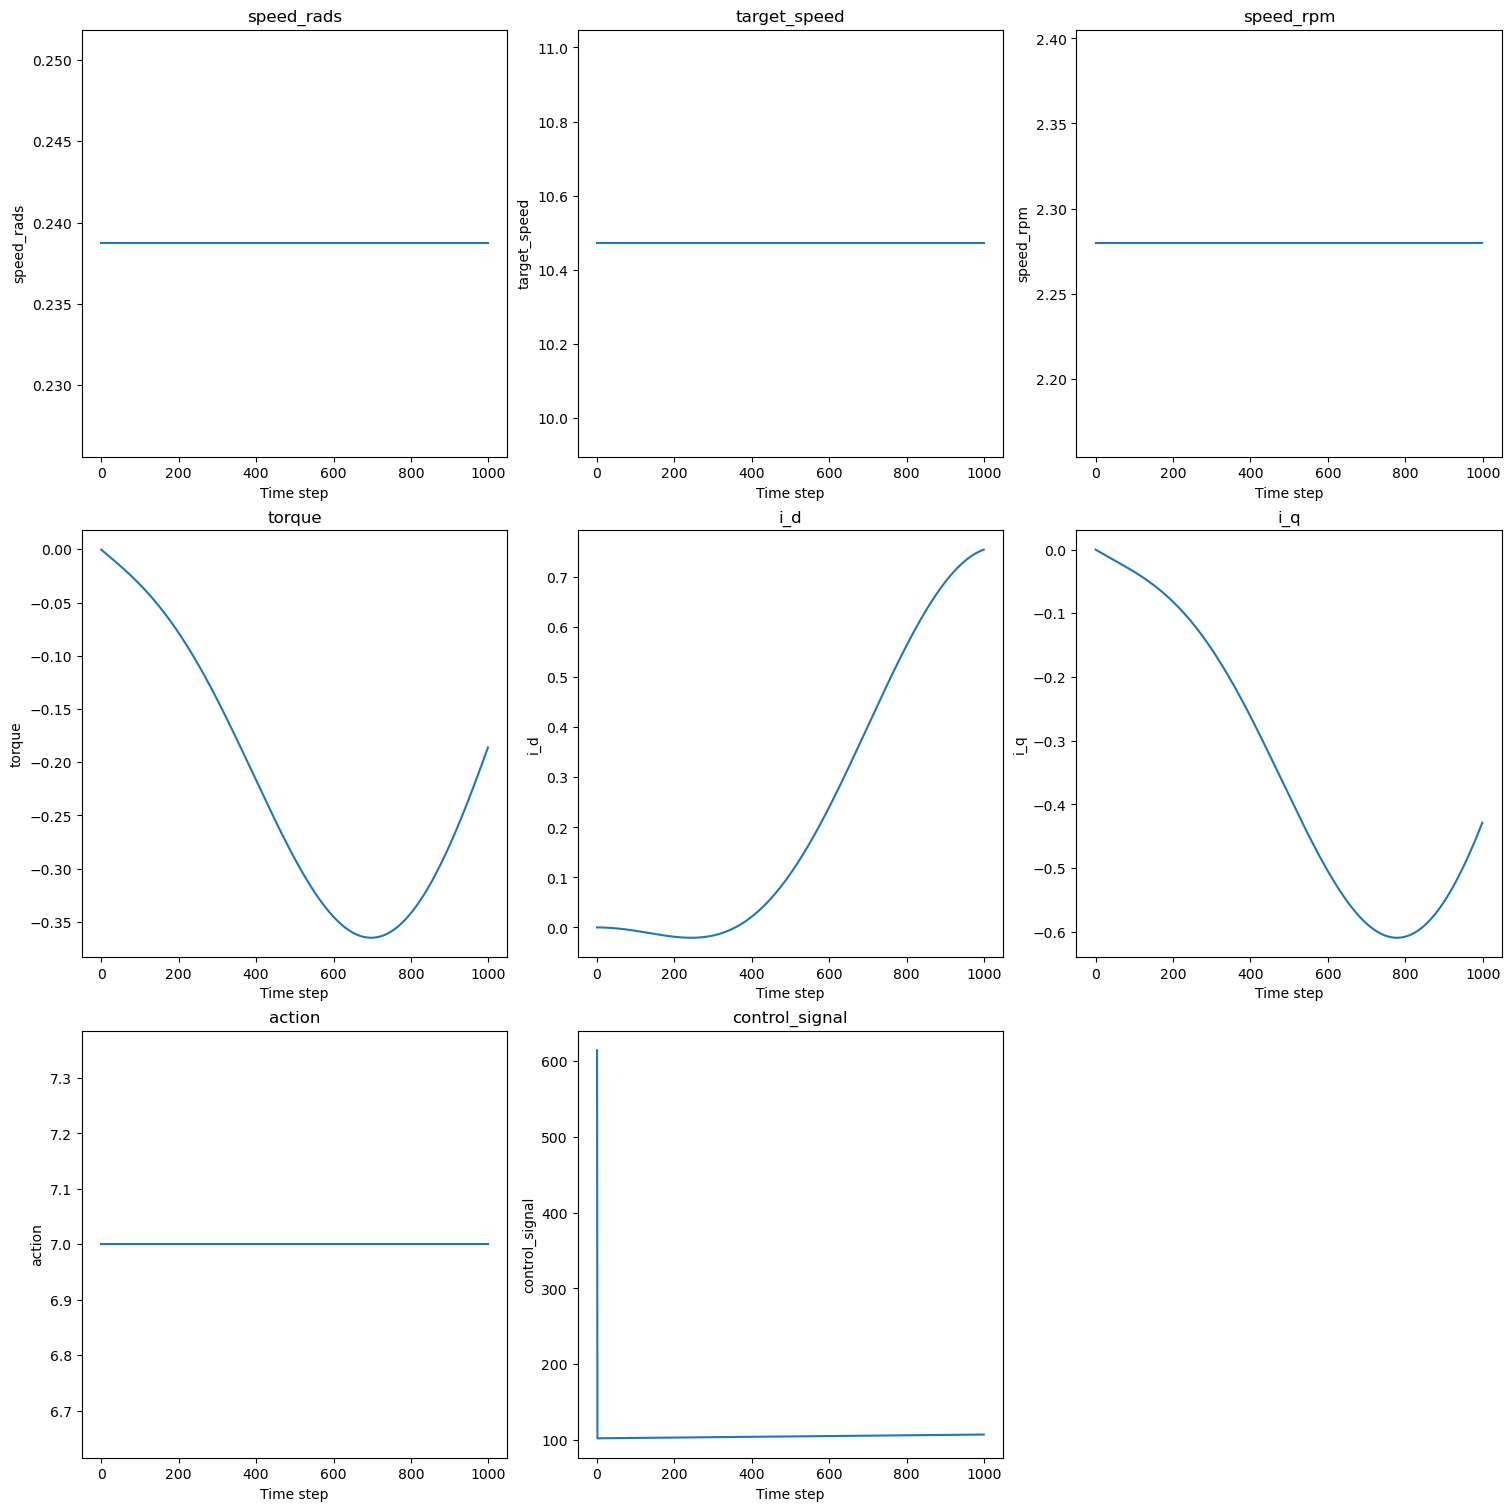

In [44]:
import gymnasium as gym
import gym_electric_motor as gem
import matplotlib.pyplot as plt
import numpy as np

# Print environment information
env = gym.make("Finite-CC-PMSM-v0")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")

# Set target speed
target_speed_rpm = 100
target_speed_rads = (target_speed_rpm * 2 * np.pi) / 60

# Initialize environment
obs, info = env.reset()
print(f"Initial observation: {obs}")

# Data collection
data = {
    "speed_rads": [],
    "target_speed": [],
    "speed_rpm": [],
    "torque": [],
    "i_d": [],
    "i_q": [],
    "action": [],
    "control_signal": []  # Added for debugging
}

# PID parameters
Kp = 10.0  # Increased for stronger response
Ki = 0.5
Kd = 0.05
integral_error = 0
last_error = 0
dt = 0.001

done = False
step = 0
max_steps = 1000

while not done and step < max_steps:
    # Get current state
    current_speed = obs[0][0]
    current_i_d = obs[0][2]
    current_i_q = obs[0][3]
    
    # Calculate errors
    speed_error = target_speed_rads - current_speed
    
    # PID control
    integral_error = np.clip(integral_error + speed_error * dt, -10, 10)
    derivative = (speed_error - last_error) / dt
    
    # Calculate control signal
    control = Kp * speed_error + Ki * integral_error + Kd * derivative
    
    # Convert to discrete action (0-7)
    discrete_action = int(np.clip(np.floor(control + 4), 0, 7))
    
    # Debug prints every 100 steps
    if step % 100 == 0:
        print(f"Step {step}:")
        print(f"Speed: {current_speed:.2f} rad/s ({current_speed * 60 / (2*np.pi):.2f} RPM)")
        print(f"Error: {speed_error:.2f}")
        print(f"Control: {control:.2f}")
        print(f"Action: {discrete_action}")
        print("---")
    
    # Step environment
    obs, reward, done, truncated, info = env.step(discrete_action)
    
    # Store data
    data["speed_rads"].append(current_speed)
    data["target_speed"].append(target_speed_rads)
    data["speed_rpm"].append((current_speed * 60) / (2 * np.pi))
    data["torque"].append(obs[0][1])
    data["i_d"].append(current_i_d)
    data["i_q"].append(current_i_q)
    data["action"].append(discrete_action)
    data["control_signal"].append(control)
    
    last_error = speed_error
    step += 1
# Vẽ chart

keys = list(data.keys())
num_plots = len(keys)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows), constrained_layout=True)

for i, key in enumerate(keys):
    r = i // cols
    c = i % cols
    ax = axs[r, c] if rows > 1 else axs[c]
    ax.plot(range(len(data[key])), data[key])
    ax.set_title(key)
    ax.set_xlabel("Time step")
    ax.set_ylabel(key)

# Ẩn các subplot thừa nếu có
for j in range(num_plots, rows*cols):
    r = j // cols
    c = j % cols
    ax = axs[r, c] if rows > 1 else axs[c]
    ax.axis('off')

plt.show()


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gym_electric_motor as gem
from gym_electric_motor.physical_systems import ConstantSpeedLoad
from gym_electric_motor.reference_generators import WienerProcessReferenceGenerator
from gym_electric_motor.visualization import MotorDashboard

env_id = 'Cont-SC-PMSM-v0'

# Define the motor parameters
motor_parameters = dict(p=3, r_s=17.932e-3, l_d=0.37e-3, l_q=1.2e-3, psi_p=65.65e-3)

# Define the nominal and limit values of the states
nominal_values = dict(omega=4000*2*np.pi/60, i=230, u=350)
limit_values = {key: 1.5 * nomin for key, nomin in nominal_values.items()}

# Define the mechanical load
load = ConstantSpeedLoad(load_initializer={'random_init': 'uniform', 'interval':[100,200] })

# Define the reference generator
rg = WienerProcessReferenceGenerator(reference_state='torque', sigma_range=(1e-3, 1e-2))

# Define the states to be plotted
visualization = MotorDashboard(state_plots=('omega','torque', 'i_sd', 'i_sq', 'u_sd', 'u_sq'))


env = gem.make(
    env_id,
    tau=1e-4,   # Sampling time
    visualization=visualization,
    motor=dict(
        motor_parameter=motor_parameters,
        limit_values=limit_values,
        nominal_values=nominal_values,
    ),
    load=load,
    reference_generator=rg,
)

In [ ]:
obs, info = env.reset()

data = {"omega": [], "torque": [], "i_sq": []}

for step in range(200):
    state = obs[0]
    omega = state[0]
    torque = state[1]
    i_sq = state[3]

    omega_ref = obs[1][0]  # reference speed

    # proportional controller (dùng u_q để điều khiển torque)
    Kp = 0.1
    u_q = Kp * (omega_ref - omega)

    # tạo action đúng shape
    action = np.zeros(env.action_space.shape)  
    action[1] = u_q  # đặt u_q vào đúng vị trí trong action array

    obs, reward, done, truncated, info = env.step(action)

    data["omega"].append(omega)
    data["torque"].append(torque)
    data["i_sq"].append(i_sq)

    if done:
        break


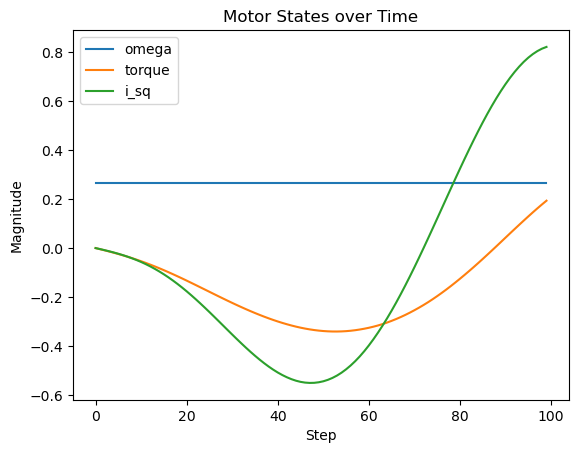

In [17]:
df = pd.DataFrame(data)
df.plot()
plt.xlabel("Step")
plt.ylabel("Magnitude")
plt.title("Motor States over Time")
plt.show()